# PDFPlumber Extraction — Block Inspection

Runs all 10 sample PDFs through the current `dmpbridge.preprocess.extract_blocks()` pipeline
and saves the raw blocks to `data/output/extracted/`.

Each block contains: `page`, `line_order`, `text`, `x0/top/x1/bottom` (bounding box),
`avg_font_size`, `font_names`, `is_bold`, `is_italic`, `label` (None until classified).

**Input:** `data/input/pdfs/sample1.pdf` … `sample10.pdf`  
**Output:** `data/output/extracted/sample1.json` … `sample10.json`


## 1 — Imports

In [1]:
import json
from pathlib import Path

import pandas as pd

from dmpbridge.preprocess import extract_blocks

_ROOT    = Path.cwd() if (Path.cwd() / "dmpbridge").exists() else Path.cwd().parent
PDF_DIR  = _ROOT / "data/input/pdfs"
OUT_DIR  = _ROOT / "data/output/extracted"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", _ROOT)
print("PDF dir exists:", PDF_DIR.exists())
print("Output dir:", OUT_DIR)


Project root: C:\Users\Nahid\dmpbridge
PDF dir exists: True
Output dir: C:\Users\Nahid\dmpbridge\data\output\extracted


## 2 — Find all PDFs

In [2]:
pdf_paths = sorted(PDF_DIR.glob("*.pdf"), key=lambda p: int(p.stem.replace("sample", "")))
print(f"Found {len(pdf_paths)} PDFs:")
for p in pdf_paths:
    print(" ", p.name)


Found 10 PDFs:
  sample1.pdf
  sample2.pdf
  sample3.pdf
  sample4.pdf
  sample5.pdf
  sample6.pdf
  sample7.pdf
  sample8.pdf
  sample9.pdf
  sample10.pdf


## 3 — Inspect one sample

In [3]:
pdf_path = pdf_paths[0]
blocks   = extract_blocks(pdf_path)
df       = pd.DataFrame(blocks)

print(f"{pdf_path.name}: {len(blocks)} blocks, {df['page'].nunique()} pages")
print()

COLS = ["page", "line_order", "text", "avg_font_size", "is_bold", "is_italic"]
display(df[COLS].head(30))


sample1.pdf: 78 blocks, 2 pages



,page,line_order,text,avg_font_size,is_bold,is_italic
0,1,1,DATA MANAGEMENT AND SHARING PLAN,11.04,True,False
1,1,2,Element 1: Data Type:,11.04,True,False
2,1,3,A. Types and amount of scientific data expecte...,11.04,True,False
3,1,4,This secondary data analysis project will anal...,11.04,False,False
4,1,5,and the publicly available NHANES cohorts (wri...,11.04,False,False
5,1,6,"The studies include (i) the RISE Study, (ii) t...",11.04,False,False
6,1,7,"(v) the PHASE Study, (vi) the AusDiab Study, (...",11.04,False,False
7,1,8,study.,11.04,False,False
8,1,9,B. Scientific data that will be preserved and ...,11.04,True,False
9,1,10,"As this is a secondary data analysis project, ...",11.04,False,False


## 4 — Font size and bold distribution

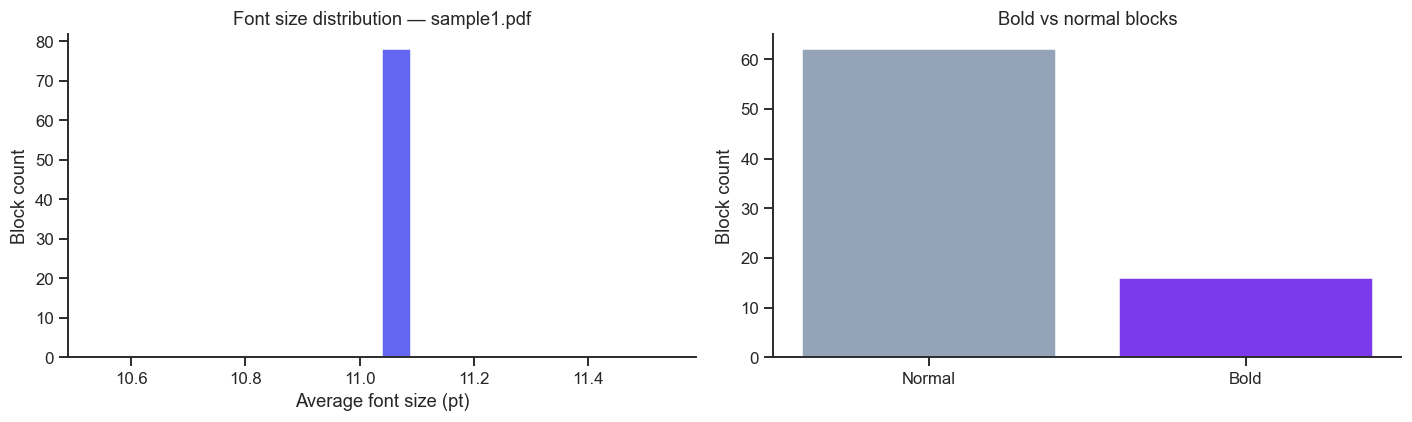

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "figure.dpi": 110})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["avg_font_size"].dropna(), bins=20, color="#6366f1", edgecolor="white")
axes[0].set_xlabel("Average font size (pt)")
axes[0].set_ylabel("Block count")
axes[0].set_title(f"Font size distribution — {pdf_path.name}")
sns.despine(ax=axes[0])

bold_counts = df["is_bold"].value_counts()
axes[1].bar(["Normal", "Bold"], [bold_counts.get(False, 0), bold_counts.get(True, 0)],
            color=["#94a3b8", "#7c3aed"], edgecolor="white")
axes[1].set_ylabel("Block count")
axes[1].set_title("Bold vs normal blocks")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


## 5 — Extract and save all 10 PDFs

In [5]:
DEBUG_COLS = ["page", "line_order", "text", "avg_font_size", "is_bold", "is_italic", "x0", "top", "x1", "bottom"]

results = []
for pdf_path in pdf_paths:
    try:
        blocks = extract_blocks(pdf_path)
        out    = OUT_DIR / f"{pdf_path.stem}.json"
        out.write_text(json.dumps(blocks, indent=2, ensure_ascii=False), encoding="utf-8")

        df_ = pd.DataFrame(blocks)
        results.append({
            "pdf":          pdf_path.name,
            "status":       "ok",
            "blocks":       len(blocks),
            "pages":        df_["page"].nunique(),
            "bold_blocks":  int(df_["is_bold"].sum()),
            "avg_font_pt":  round(df_["avg_font_size"].mean(), 2),
            "output":       out.name,
        })
        print(f"  {pdf_path.name}: {len(blocks)} blocks → {out.name}")
    except Exception as e:
        results.append({"pdf": pdf_path.name, "status": f"FAILED: {e}",
                        "blocks": None, "pages": None, "bold_blocks": None,
                        "avg_font_pt": None, "output": None})
        print(f"  FAILED: {pdf_path.name}: {e}")

summary = pd.DataFrame(results)
display(summary)


  sample1.pdf: 78 blocks → sample1.json


  sample2.pdf: 171 blocks → sample2.json


  sample3.pdf: 69 blocks → sample3.json
  sample4.pdf: 78 blocks → sample4.json


  sample5.pdf: 80 blocks → sample5.json
  sample6.pdf: 24 blocks → sample6.json
  sample7.pdf: 17 blocks → sample7.json
  sample8.pdf: 59 blocks → sample8.json


  sample9.pdf: 85 blocks → sample9.json
  sample10.pdf: 68 blocks → sample10.json


,pdf,status,blocks,pages,bold_blocks,avg_font_pt,output
0,sample1.pdf,ok,78,2,16,11.04,sample1.json
1,sample2.pdf,ok,171,5,42,11.25,sample2.json
2,sample3.pdf,ok,69,3,0,11.90,sample3.json
3,sample4.pdf,ok,78,2,1,12.00,sample4.json
4,sample5.pdf,ok,80,2,13,11.04,sample5.json
5,sample6.pdf,ok,24,1,1,12.00,sample6.json
6,sample7.pdf,ok,17,1,1,11.04,sample7.json
7,sample8.pdf,ok,59,2,7,9.84,sample8.json
8,sample9.pdf,ok,85,3,0,11.55,sample9.json
9,sample10.pdf,ok,68,2,7,10.98,sample10.json


## 6 — Cross-sample comparison

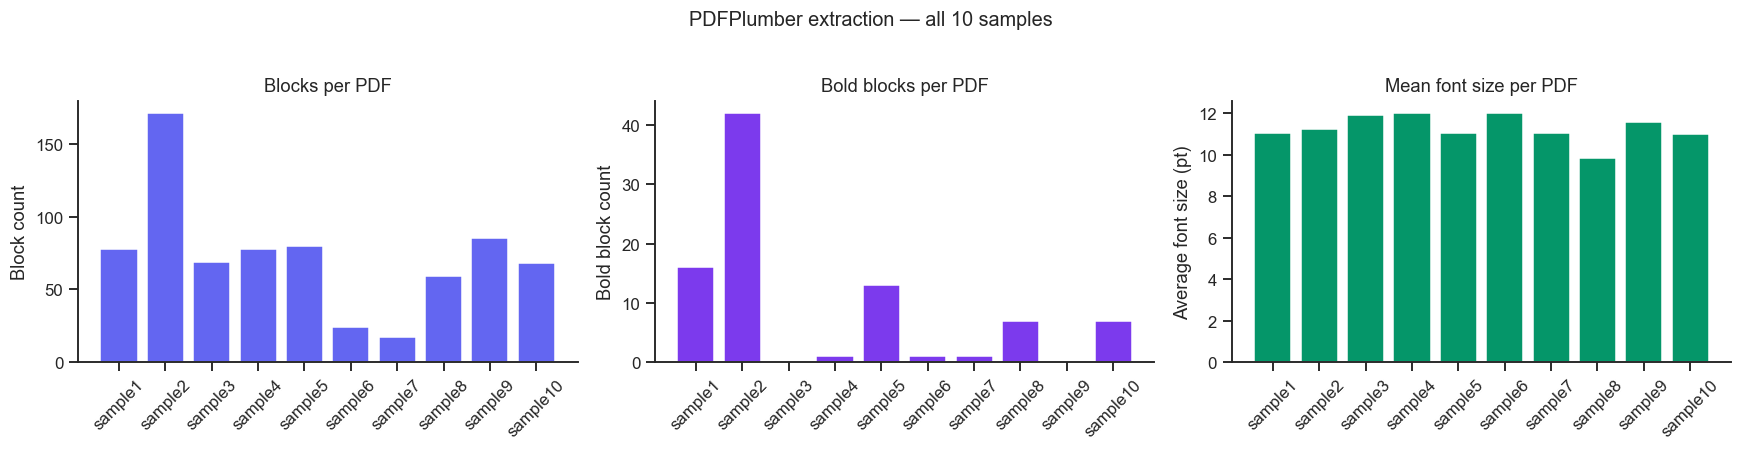

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

names = summary["pdf"].str.replace(".pdf", "", regex=False)

axes[0].bar(names, summary["blocks"], color="#6366f1", edgecolor="white")
axes[0].set_ylabel("Block count")
axes[0].set_title("Blocks per PDF")
axes[0].tick_params(axis="x", rotation=45)
sns.despine(ax=axes[0])

axes[1].bar(names, summary["bold_blocks"], color="#7c3aed", edgecolor="white")
axes[1].set_ylabel("Bold block count")
axes[1].set_title("Bold blocks per PDF")
axes[1].tick_params(axis="x", rotation=45)
sns.despine(ax=axes[1])

axes[2].bar(names, summary["avg_font_pt"], color="#059669", edgecolor="white")
axes[2].set_ylabel("Average font size (pt)")
axes[2].set_title("Mean font size per PDF")
axes[2].tick_params(axis="x", rotation=45)
sns.despine(ax=axes[2])

plt.suptitle("PDFPlumber extraction — all 10 samples", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
